# Decision Tree and Random Forests

In this notebook, we will be exploring Decision Trees and Random Forests using the existing Titanic dataset.

We will follow the basic preprocessing pipeline, train/validation split, and logistic regression baseline of the initial titanic.ipynb. 

We will then add on a Decision Tree, try different max_depth, and plot how accuracy changes. Similarly, we will create a Random Forest, try different n_estimators, and plot how accuracy changes. 

This notebook aims to reinforce the learning of decision tree and random forests. 

## 01. Load Data

In [2]:
# Import Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Set Up Complete")

# Load Data
titanic = pd.read_csv("train.csv")
titanic.head()

Set Up Complete


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 02. Train/validation split, Basic Preprocessing Pipeline

Drop Passenger ID, Name, Ticket, Cabin columns
Separate X and y
Train/validation split
Fit preprocessing pipeline only on X_train

In [5]:
# Drop Passenger ID, Name, Ticket, Cabin
titanic_v2 = titanic.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Train/Test Split
from sklearn.model_selection import train_test_split
X = titanic_v2.drop(columns=["Survived"])
y = titanic_v2["Survived"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numerical and categorical columns
numerical_columns = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_columns = ["Sex", "Embarked"]

# Import necessary libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Build preprocessing
numerical_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("encoder", OneHotEncoder())])

# Combine both
preprocessing = ColumnTransformer([("num", numerical_transformer, numerical_columns),
                                   ("cat", categorical_transformer, categorical_columns)],
                                   remainder = 'passthrough')

## 03. Logistic Regression Baseline

Fit logistic regression model to set baseline

In [6]:
# Add Logistic Regression
from sklearn.linear_model import LogisticRegression
model = Pipeline([("preprocessing", preprocessing),
                  ("classifier", LogisticRegression(max_iter=1000))])

# Train the model
model.fit(X_train, y_train)

# Predict on validation set
y_pred = model.predict(X_valid)

# Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_valid, y_pred)
print(f"Accuracy of Logistic Regression Model: {accuracy:.4f}")

Accuracy of Logistic Regression Model: 0.8101


## 04. Decision Tree
- try different max_depth
- collect accuracies
- plot accuracy vs max depth

In [8]:
# Decision Trees Pipeline
from sklearn.tree import DecisionTreeClassifier
decision_tree = Pipeline([("preprocessing", preprocessing),
                  ("classifier", DecisionTreeClassifier(max_depth=3, random_state=42))])

decision_tree.fit(X_train, y_train)
decision_tree_y_pred = decision_tree.predict(X_valid)
accuracy_decision_tree = accuracy_score(y_valid, decision_tree_y_pred)
print(f"Accuracy of Decision Tree Model: {accuracy_decision_tree:.4f}")

Accuracy of Decision Tree Model: 0.7989


In [13]:
# Try different max_depth
decision_tree_accuracies = []
for depth in range (1, 11):
    decision_tree = Pipeline([("preprocessing", preprocessing),
                  ("classifier", DecisionTreeClassifier(max_depth=depth, random_state=42))])
    decision_tree.fit(X_train, y_train)
    decision_tree_y_pred = decision_tree.predict(X_valid)
    accuracy_decision_tree = accuracy_score(y_valid, decision_tree_y_pred)
    decision_tree_accuracies.append(accuracy_decision_tree)

# Print results
for depth, accuracy in zip(range(1, 11), decision_tree_accuracies):
    print(f"max_depth={depth}: accuracy={accuracy:.4f}")    

max_depth=1: accuracy=0.7821
max_depth=2: accuracy=0.7654
max_depth=3: accuracy=0.7989
max_depth=4: accuracy=0.7989
max_depth=5: accuracy=0.7989
max_depth=6: accuracy=0.7989
max_depth=7: accuracy=0.8045
max_depth=8: accuracy=0.7821
max_depth=9: accuracy=0.7989
max_depth=10: accuracy=0.7877


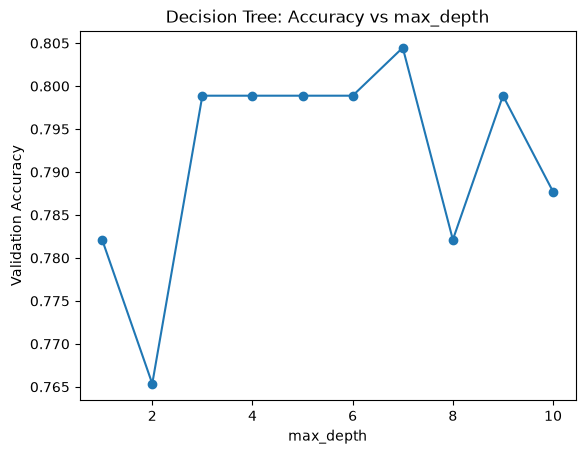

In [14]:
# Plot accuracies vs max_depth

import matplotlib.pyplot as plt
plt.plot(range(1, 11), decision_tree_accuracies, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Validation Accuracy")
plt.title("Decision Tree: Accuracy vs max_depth")
plt.show()

## 05. Random Forest
- try different n_estimators
- collect accuracies
- plot accuracy vs n_estimators

In [16]:
# Random Forest Pipeline
from sklearn.ensemble import RandomForestClassifier
random_forest = Pipeline([("preprocessing", preprocessing),
                  ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))])

random_forest.fit(X_train, y_train)
random_forest_y_pred = random_forest.predict(X_valid)
accuracy_random_forest = accuracy_score(y_valid, random_forest_y_pred)
print(f"Accuracy of Random Forest Model: {accuracy_random_forest:.4f}")

Accuracy of Random Forest Model: 0.8045


In [17]:
# Try different n_estimators
n_estimators = [1, 5, 10, 25, 50, 100, 200]
random_forest_accuracies = []
for n_estimator in n_estimators:
    random_forest = Pipeline([("preprocessing", preprocessing),
                  ("classifier", RandomForestClassifier(n_estimators=n_estimator, random_state=42))])
    random_forest.fit(X_train, y_train)
    random_forest_y_pred = random_forest.predict(X_valid)
    accuracy_random_forest = accuracy_score(y_valid, random_forest_y_pred)
    random_forest_accuracies.append(accuracy_random_forest)

# Print results
for n_estimator, accuracy in zip(n_estimators, random_forest_accuracies):
    print(f"n_estimator={n_estimator}: accuracy={accuracy:.4f}")    

n_estimator=1: accuracy=0.8268
n_estimator=5: accuracy=0.7933
n_estimator=10: accuracy=0.7877
n_estimator=25: accuracy=0.8045
n_estimator=50: accuracy=0.8101
n_estimator=100: accuracy=0.8045
n_estimator=200: accuracy=0.8045


## 06. Compare results

## 07. Conclusion